# M9 DLNLP - ASSIGNMENT 1
## Text pre-processing
Overview:

This assignment focuses on pre-processing textual data and visualizing the processed content using a word cloud.

The specific tasks are given below:

## Tasks
1. Load and inspect Airline Reviews data
2. Perform Text pre-processing
    - lowercasing
    - remove HTML
    - removing punctuation & numbers
    - normalizing repeated characters
    - removing stopwords ('flight', 'airline', 'air', ‘airport’,'plane', 'aircraft', 'service', 'staff', 'crew', 'cabin',’one’)
    - lemmatization
3. Generate and visualize a word cloud to identify the most frequently occurring words.

## Import Libraries

In [1]:
import warnings
warnings.filterwarnings('ignore')

import html
import re

import matplotlib.pyplot as plt
import pandas as pd
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from wordcloud import WordCloud

# nltk corpora (stopwords, wordnet, punkt) are downloaded once during environment setup
lemmatizer = WordNetLemmatizer()

## Task 1: Load and Inspect Data

In [2]:
# 'Unnamed: 0' is a leftover row index from the CSV export
df = pd.read_csv('Airline Reviews.csv').drop(columns=['Unnamed: 0'])
df.head()

,Airline Name,Overall_Rating,Review,Type Of Traveller,Seat Type,Date Flown,Recommended
0,AB Aviation,9,Moroni to Moheli. Turned out to be a pretty ...,Solo Leisure,Economy Class,Nov-19,yes
1,AB Aviation,1,Moroni to Anjouan. It is a very small airline...,Solo Leisure,Economy Class,Jun-19,no
2,AB Aviation,1,Anjouan to Dzaoudzi. A very small airline an...,Solo Leisure,Economy Class,Jun-19,no
3,Adria Airways,1,Please do a favor yourself and do not fly wi...,Solo Leisure,Economy Class,Sep-19,no
4,Adria Airways,1,Do not book a flight with this airline! My fr...,Couple Leisure,Economy Class,Sep-19,no


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22329 entries, 0 to 22328
Data columns (total 7 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   Airline Name       22329 non-null  object
 1   Overall_Rating     22329 non-null  int64 
 2   Review             22329 non-null  object
 3   Type Of Traveller  19433 non-null  object
 4   Seat Type          21761 non-null  object
 5   Date Flown         19417 non-null  object
 6   Recommended        22329 non-null  object
dtypes: int64(1), object(6)
memory usage: 1.2+ MB


In [4]:
df.isnull().sum()

Airline Name            0
Overall_Rating          0
Review                  0
Type Of Traveller    2896
Seat Type             568
Date Flown           2912
Recommended             0
dtype: int64

In [5]:
# Distribution used later to segment the word clouds
df['Recommended'].value_counts()

Recommended
no     14527
yes     7802
Name: count, dtype: int64

## Task 2: Text Pre-processing

Cleaning pipeline applied to each review, in order:
1. Un-escape and strip HTML
2. Lowercase
3. Normalize repeated characters (e.g. "sooo" -> "soo")
4. Remove punctuation & numbers
5. Tokenize
6. Remove NLTK stopwords (their common forms are already in the list, e.g. "was", "is")
7. Lemmatize
8. Remove the domain-specific stopwords given in the assignment (after lemmatizing, so inflected forms like "flights"/"aircrafts" -> "flight"/"aircraft" are caught too)

In [6]:
stop_words = set(stopwords.words('english'))
domain_stop_words = {
    'flight', 'airline', 'air', 'airport', 'plane',
    'aircraft', 'service', 'staff', 'crew', 'cabin', 'one'
}

In [7]:
def preprocess_review(text):
    text = html.unescape(text)
    text = re.sub(r'<[^>]+>', ' ', text)            # remove HTML tags
    text = text.lower()
    text = re.sub(r'([a-z])\1{2,}', r'\1\1', text)  # normalize repeated characters
    text = re.sub(r'[^a-z\s]', ' ', text)            # remove punctuation & numbers

    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in stop_words]         # remove NLTK stopwords first
    tokens = [lemmatizer.lemmatize(t) for t in tokens]          # lemmatize remaining content words
    tokens = [t for t in tokens if t not in domain_stop_words]  # remove domain stopwords (post-lemmatization)

    return ' '.join(tokens)


df['Cleaned_Review'] = df['Review'].apply(preprocess_review)

#### Checking a review before and after cleaning

In [8]:
df['Review'][0]

"  Moroni to Moheli. Turned out to be a pretty decent airline. Online booking worked well, checkin and boarding was fine and the plane looked well maintained. Its a very short flight - just 20 minutes or so so i didn't expect much but they still managed to hand our a bottle of water and some biscuits which i though was very nice. Both flights on time."

In [9]:
df['Cleaned_Review'][0]

'moroni moheli turned pretty decent online booking worked well checkin boarding fine looked well maintained short minute expect much still managed hand bottle water biscuit though nice time'

## Task 3: Word Cloud

Generate a word cloud of the cleaned reviews, and also segment it by `Recommended` to compare the most frequent words between recommended and not-recommended flights.

In [10]:
def generate_wordcloud(text, title):
    wordcloud = WordCloud(width=800, height=400, background_color='white').generate(text)
    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')
    plt.title(title)
    plt.show()

#### Overall Word Cloud

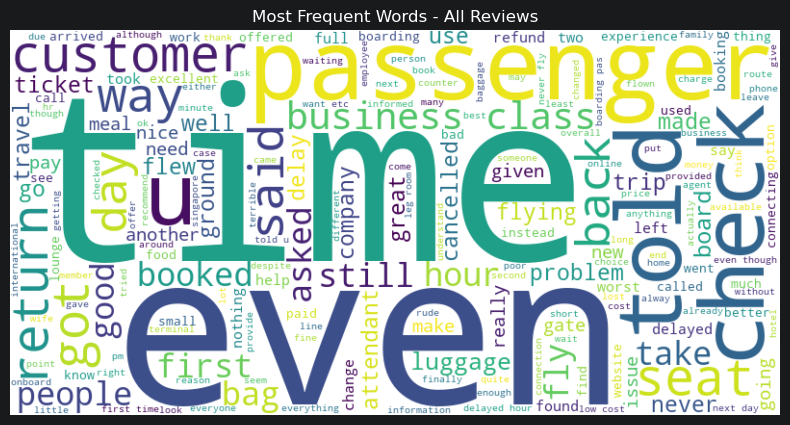

In [11]:
all_reviews = df['Cleaned_Review'].str.cat(sep=' ')
generate_wordcloud(all_reviews, 'Most Frequent Words - All Reviews')

#### Word Clouds by Recommendation

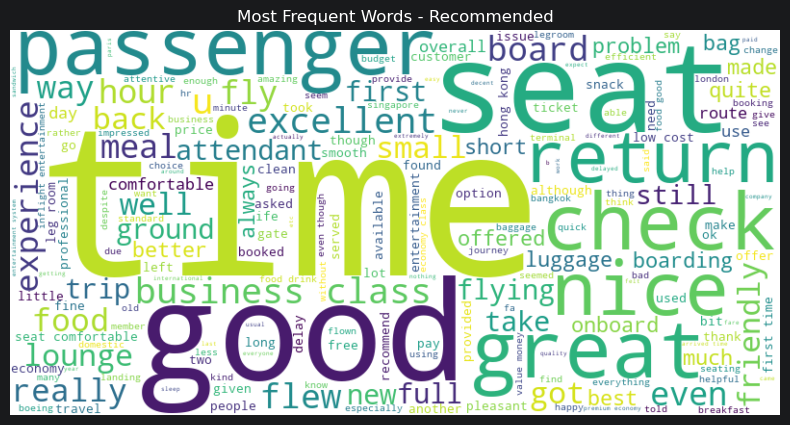

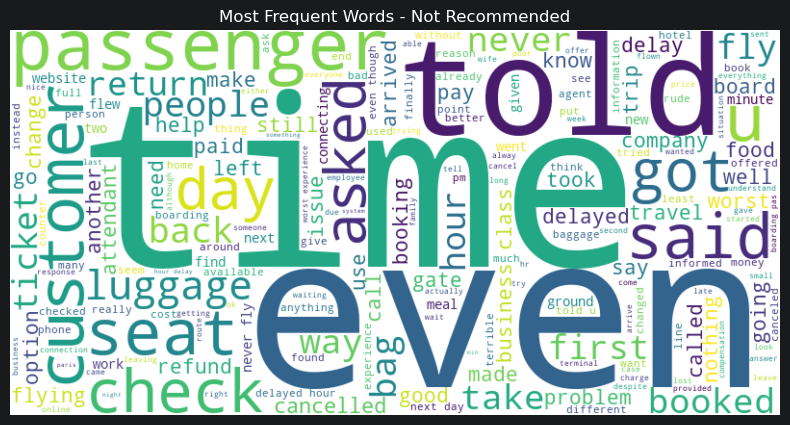

In [12]:
recommended_reviews = df[df['Recommended'] == 'yes']['Cleaned_Review'].str.cat(sep=' ')
not_recommended_reviews = df[df['Recommended'] == 'no']['Cleaned_Review'].str.cat(sep=' ')

generate_wordcloud(recommended_reviews, 'Most Frequent Words - Recommended')
generate_wordcloud(not_recommended_reviews, 'Most Frequent Words - Not Recommended')

## Conclusion

The pre-processing pipeline (HTML/entity removal, lowercasing, repeated-character normalization, punctuation/number stripping, stopword removal with the domain-specific list from the assignment, and lemmatization) reduces each review to its most informative words, which is what makes the word clouds readable and non-trivial.

The overall word cloud highlights the words travellers use most often regardless of outcome (e.g. terms about boarding, seating, delay, luggage). Comparing the "Recommended" vs "Not Recommended" word clouds shows a shift from words tied to comfort and good experience towards words tied to delay, cancellation, refund and complaint — the vocabulary itself tracks sentiment even without an explicit sentiment score.

This pre-processing and word-cloud approach follows the pattern established in the "M9 Unit 2 Text Preprocessing and Data Preparation" class notebook, adapted here to the Airline Reviews dataset and the domain stopword list required by this assignment.